## Example of sensibility analysis

This is the notebook version of the example in read the doc.
The following lines present a small example of simulation the sap flux from an Arabidopsis de-topped root plunged in a hydroponic solution at a hydrostatic pressure of 0.4 Mpa when its  base is at the atmospheric pressure.

With a simple sensibility analysis on the two conductances

In [1]:
import sys; print('Python %s on %s' % (sys.version, sys.platform))
sys.path.extend(['../src'])

Python 3.9.13 | packaged by conda-forge | (main, May 27 2022, 16:58:50) 
[GCC 10.3.0] on linux


In [2]:
from hydroroot.display import plot
from hydroroot.read_file import read_archi_data
from hydroroot.main import hydroroot_flow, root_builder
from hydroroot.conductance import axial

# Read the architecture file and give the architecture properties:
- radius of the primary in meter
- a decrease factor between root orders

In [3]:
df = read_archi_data('data/plant-01.txt')
r_pr = 7e-05 # radius of the primary in m
beta = 0.7 # decrease factor at each order

# Building the MTG from the file

In [4]:
g, primary_length, total_length, surface, seed = root_builder(df=df, segment_length=1.0e-4, order_decrease_factor = beta, ref_radius = r_pr)

Some conductance data versus distance to tip

In [5]:
k_radial_data=([0, 0.2],[30.0,30.0])
K_axial_data=([0, 0.2],[3.0e-7,4.0e-4])

# sensibility analysis on axial and radial conductances

Simple analysis with a loop on factors applied to the two conductances.

Flux and equivalent conductance calculation, for a root in an external hydroponic medium at 0.4 MPa, its base at 0.1 MPa, and with the conductances set above.

In [6]:
results = {} # dictionnary to record some data
results['K scale'] = [] # list where the K scale are recorded, idem below for other variables
results['k scale'] = []
results['keq'] = []
results['jv'] = []
for K_scale in [0.25, 0.5, 1.0, 1.5 ,2.0]: 
    Kax = axial(acol=K_axial_data,scale=K_scale) # multiply K_axial_data by K_scale    
    for k_scale in [0.25, 0.5, 1.0, 1.5 ,2.0]: 
        kr = axial(acol=k_radial_data,scale=k_scale) # multiply k_radial by k_scale
        g, keq, jv = hydroroot_flow(g, psi_e = 0.4, psi_base = 0.1, axial_conductivity_data = Kax, radial_conductivity_data = kr)
        results['K scale'].append(K_scale)
        results['k scale'].append(k_scale)
        results['keq'].append(keq)
        results['jv'].append(jv)
        print('K_scale: ', K_scale, 'k_scale: ', k_scale, 'keq: ', keq, 'jv: ', jv)

K_scale:  0.25 k_scale:  0.25 keq:  0.0023990952654609258 jv:  0.0007197285796382778
K_scale:  0.25 k_scale:  0.5 keq:  0.0037568653836499624 jv:  0.001127059615094989
K_scale:  0.25 k_scale:  1.0 keq:  0.005387689996992873 jv:  0.0016163069990978622
K_scale:  0.25 k_scale:  1.5 keq:  0.0064122561959869375 jv:  0.0019236768587960816
K_scale:  0.25 k_scale:  2.0 keq:  0.007154385642505493 jv:  0.0021463156927516483
K_scale:  0.5 k_scale:  0.25 keq:  0.0028190391469473304 jv:  0.0008457117440841993
K_scale:  0.5 k_scale:  0.5 keq:  0.0047981905309218515 jv:  0.0014394571592765556
K_scale:  0.5 k_scale:  1.0 keq:  0.007513730767299925 jv:  0.002254119230189978
K_scale:  0.5 k_scale:  1.5 keq:  0.009373513509749253 jv:  0.0028120540529247766
K_scale:  0.5 k_scale:  2.0 keq:  0.010775379993985746 jv:  0.0032326139981957245
K_scale:  1.0 k_scale:  0.25 keq:  0.003104148388469553 jv:  0.0009312445165408661
K_scale:  1.0 k_scale:  0.5 keq:  0.005638078293894661 jv:  0.0016914234881683986
K_sca

# Displaying and recording results
Passing the results to a Pandas DataFrame that is easy to manipulate

In [7]:
import pandas as pd
# to display inline plots in the notebook
%matplotlib inline

In [8]:
dr=pd.DataFrame(results)

<AxesSubplot:xlabel='k scale', ylabel='jv'>

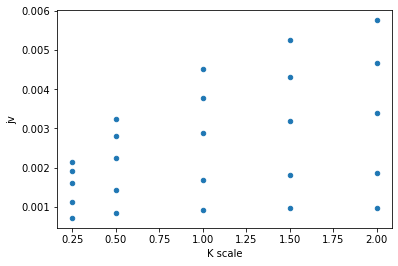

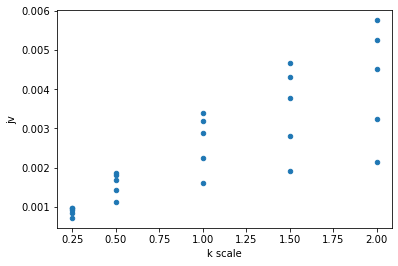

In [9]:
dr.plot.scatter('K scale','jv')
dr.plot.scatter('k scale','jv')

In [34]:
dr.to_csv('results.csv') # save to a comma separated csv file